<a href="https://colab.research.google.com/github/FX9919/Final-project-used-car-analysis/blob/main/Final_project_used_car_Load%2C_Explore_%26_Clean_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**the target is price about that thing affect the price of used** **car**

       و الموضوع يعتمد بالبدايه اني استكشف البيانات و اعرف الاشياء المفقوده و احذفها او  اعبيها بي المتوسط و احذف التكرارات و الاعمده الي ما احتاجها بي التحليل و الي اكيد بتاخذ مساحه و الموضوع يعتمد اكيد على التارقت الي اخترته(clean data) الى (messy data)هدف المشروع و الخطوه الاولى تعتمد  و بشكل كبير على  تحويل   

**import libraries** (استدعاء المكتبات المهمه لي تحليل البيانات)

In [152]:
import numpy as np              # العمليات الرياضيه
import pandas as pd             # لمعالجة البيانات
import matplotlib.pyplot as plt # لي الرسم
import seaborn as sns           # لرسم احصائي اكثر و اوضح

In [153]:
df = pd.read_csv('vehicles.csv')

In [154]:
print(df.head()) # to see the frist 5 rows of the dataset
print(df.shape) # return the number of rows and column
print(df.info()) # to see the name of column , type missing values

           id                                                url  \
0  7222695916  https://prescott.craigslist.org/cto/d/prescott...   
1  7218891961  https://fayar.craigslist.org/ctd/d/bentonville...   
2  7221797935  https://keys.craigslist.org/cto/d/summerland-k...   
3  7222270760  https://worcester.craigslist.org/cto/d/west-br...   
4  7210384030  https://greensboro.craigslist.org/cto/d/trinit...   

                   region                         region_url    price  year  \
0                prescott    https://prescott.craigslist.org   6000.0   NaN   
1            fayetteville       https://fayar.craigslist.org  11900.0   NaN   
2            florida keys        https://keys.craigslist.org  21000.0   NaN   
3  worcester / central MA   https://worcester.craigslist.org   1500.0   NaN   
4              greensboro  https://greensboro.craigslist.org   4900.0   NaN   

  manufacturer model condition cylinders  ... size  type paint_color  \
0          NaN   NaN       NaN       NaN  ..

In [155]:
print(df['posting_date'].dtype)

object


In [151]:
df['posting_date'] = pd.to_datetime(df['posting_date'])
print(df['posting_date'].dtype)

datetime64[ns, UTC]


In [156]:
print(df['cylinders'].dtype)

object


In [157]:
df['cylinders'] =pd.to_numeric(df['cylinders'], errors='coerce')
print(df['cylinders'].dtype)

float64


| العمود       | المعنى                      |
| ------------ | --------------------------- |
| id           | رقم الاعلان                 |
| url          | رابط الاعلان                |
| region       | المدينة او المنطقة          |
| price        | سعر السيارة                 |
| year         | سنة الصنع                   |
| manufacturer | الشركه(toyota, ford) |
| model        | موديل السيارة               |
| condition    | حالة السيارة                |
| cylinders    | عدد السلندرات               |
| fuel         | نوع الوقود                  |
| odometer     | عدد الكيلومترات             |
| transmission | نوع القير                   |
| drive        | نوع الدفع                   |
| type         | نوع السيارة (SUV, sedan) |
| paint_color  | لون السياره                |
| state        | الولايه                    |
| lat / long   | الموقع الجغرافي             |


In [158]:
df.isnull().sum() # to see the missing values in each column

,0
id,0
url,0
region,1
region_url,1
price,1
year,140
manufacturer,648
model,185
condition,5866
cylinders,13463


In [159]:
df.isna().mean()*100 # to count percetage missing value

,0
id,0.000000
url,0.000000
region,0.007428
region_url,0.007428
price,0.007428
year,1.039887
manufacturer,4.813192
model,1.374137
condition,43.571269
cylinders,100.000000


In [160]:
df.duplicated().sum() # to count duplicated rows

np.int64(0)

حاليا بحذف العاوميد الي ما احتاجها ,لكن  قبل بشرح كل واحد قبل احذفه ليه ما احتاجه ولا بستفيد منه  وليه مو مهم

url  هو عباره عن رابط الاعلان الخاص بسياره ما بيفيدني
 ليه حذفته ؟
*   كل سياره لها رابط خاص وتختلف
*   ما اقدر استفيد منها في التحليل


region_url  هو يمثل رابط الموقع الخاص بي مدينه معينه
 ليه حذفته ؟
*   يعتبر معلومه مكرره

image_url رابط لي صور السياره
ليه حذفته ؟


*  (تعتبر تحت مسمى ميزه غير مرتبطه بي المشكله) هدفي تحليل بيانات مو صور
*   الصور غالبا ما بتفيديني بي معلومات السعر وتقدير مبلغ السياره

description وصف يختص بي صاحب السياره  
ليه حذفته ؟


*   وصف وكلام كثير ما راح استفيد منه غالبا
*    Unstructured data

county الدوله
ليه حذقته ؟
*   لاحظت انه جدا ناقصه وتعتبر قيم مفقوده  




In [161]:
#url link to the advertisement  (not useful for analysis)
#region_url website link ( we already have the region name)
#image_url link to the car image  (not useful   for numerical data analysis)
#description text description
#county column with many missing values

In [165]:
def clean_data(df):
    df =df.fillna(df.median(numeric_only=True)) # fill missing values using the medisn
# median is morre strong to outliers then the mean
# ( ليش اخترت الميدين ؟ بما انا هدفي اعبي القيم الرقميه  مثل السعر هو افضل اختيار لنه ما يتاثر من القيم الكبيره زي المتوسط الحسابي )
    df= df.drop(columns=['url','region_url','image_url','description','county'], errors='ignore')# remove unnecessary columns
    df= df.drop_duplicates()# remove duplicated rows
    df= df[df["price"] > 100]# filterlow prices
    df= df[df["price"] < 100000]# filter high prices
    p99 = df["price"].quantile(0.99) # filter high prices
    df['price'] = np.where(df['price'] > p99, p99, df['price'])
    return df
df = clean_data(df)

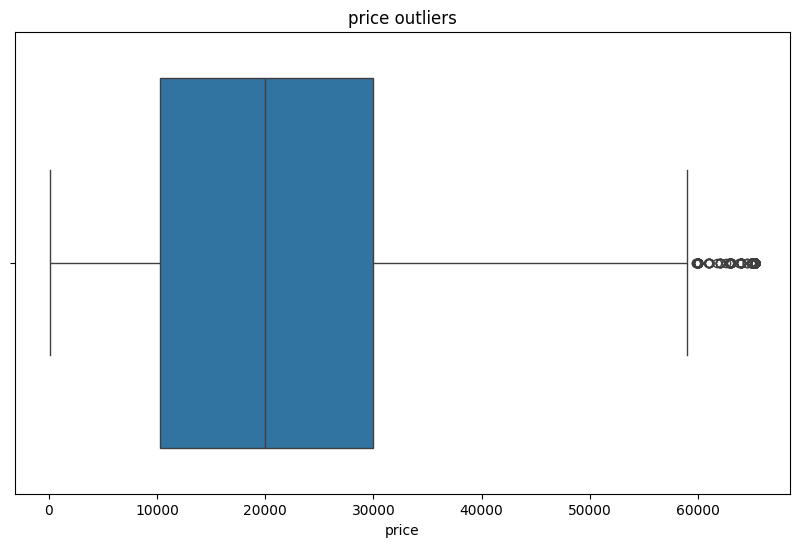

In [166]:
plt.figure(figsize=(10, 6))
sns.boxplot(x= df['price'])
plt.title('price outliers')
plt.show() # the boxploot show the most car prices are around 20,000

In [167]:
print(df.isnull().sum())  # verify remaining missing values

id                  0
region              1
price               0
year                0
manufacturer      599
model             167
condition        5477
cylinders       12846
fuel              136
odometer            0
title_status      290
transmission       77
VIN              4196
drive            3689
size             9401
type             2288
paint_color      2743
state               1
lat                 0
long                0
posting_date       23
dtype: int64


In [168]:
print((df["price"] > 0).all())  # ensure all prices are positive

True


In [169]:
print(df.shape)

(12846, 21)


In [170]:
df = clean_data(df) # save the clean dataset  into  new csv
df.to_csv('cleaned_vehicles.csv', index=False)

**------------------------------------------------------------------**